***Tên: Bùi Ngọc Bảo Trân***

***ID: 25MS33062***

<div align="center">

# **HOMEWORK 2**

</div>

## Đề bài

Thực hiện **phát hiện vật thể (Object Detection)** trong nhà (indoor objects) trên bộ dữ liệu synthetic `Dataset_Homework2/SyntheticIndoorObjectDetectionDataset` (nguồn: Roboflow — *Indoor Objects*, annotation dạng **Pascal VOC XML**).

**Yêu cầu:**
1. Thực hiện phát hiện vật thể trong nhà trên bộ dữ liệu trên.
2. So sánh, đánh giá các mô hình dùng để thực hiện phát hiện vật thể.
3. Đề xuất cải thiện nếu có.

**Cách tiếp cận:** Fine-tune và so sánh 3 mô hình pretrained thuộc 2 trường phái kiến trúc khác nhau:
- **YOLOv8n** (Ultralytics, pretrained COCO) — one-stage, nhẹ, nhanh.
- **YOLOv8s** (Ultralytics, pretrained COCO) — one-stage, capacity lớn hơn, để so sánh trade-off tốc độ/độ chính xác.

## 0. Cài đặt môi trường & thư viện

Thư viện chính:
- `torch`, `torchvision` — pretrained backbone/Faster R-CNN, huấn luyện.
- `ultralytics` — YOLOv8 (pretrained COCO), fine-tune, đánh giá.
- `pandas`, `numpy`, `matplotlib`, `seaborn`, `Pillow`, `opencv-python` — EDA, xử lý ảnh, trực quan hoá.

Nếu chưa có `ultralytics`, cell dưới sẽ tự cài vào đúng môi trường `msa` đang chạy kernel này.

In [1]:
import sys, subprocess

def _pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

try:
    import ultralytics  # noqa: F401
except ImportError:
    print("Đang cài ultralytics vào môi trường hiện tại...")
    _pip_install("ultralytics")
    import ultralytics  # noqa: F401

print("Python executable:", sys.executable)
print("ultralytics version:", ultralytics.__version__)

Python executable: /opt/miniconda3/envs/msa/bin/python
ultralytics version: 8.4.123


In [2]:
import os
import glob
import random
import shutil
import time
import warnings
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image

import torch
import torchvision

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Chọn device tốt nhất hiện có (CUDA > MPS > CPU) ---
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("Torch version      :", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device được chọn    :", DEVICE)

Torch version      : 2.13.0
Torchvision version: 0.28.0
Device được chọn    : mps


## 1. Khám phá dữ liệu (EDA)

Dataset gồm 3 tập `train` / `valid` / `test`, mỗi ảnh `.jpg` đi kèm 1 file `.xml` (Pascal VOC) chứa bounding box + nhãn lớp. Ảnh đã được Roboflow resize về `640x640`.

In [3]:
DATA_ROOT = Path("Dataset_Homework2/SyntheticIndoorObjectDetectionDataset")
SPLITS = ["train", "valid", "test"]


def parse_voc_xml(xml_path):
    """Đọc 1 file Pascal VOC XML, trả về (width, height, list[objects])."""
    root = ET.parse(xml_path).getroot()
    size = root.find("size")
    w, h = float(size.find("width").text), float(size.find("height").text)
    objs = []
    for obj in root.findall("object"):
        name = obj.find("name").text
        b = obj.find("bndbox")
        xmin, xmax = float(b.find("xmin").text), float(b.find("xmax").text)
        ymin, ymax = float(b.find("ymin").text), float(b.find("ymax").text)
        objs.append({"class": name, "xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax})
    return w, h, objs


def build_annotation_df(data_root=DATA_ROOT, splits=SPLITS):
    rows = []
    for split in splits:
        xml_files = sorted(glob.glob(str(data_root / split / "*.xml")))
        for xp in xml_files:
            stem = Path(xp).stem
            w, h, objs = parse_voc_xml(xp)
            if not objs:
                rows.append({
                    "split": split, "filename": stem, "img_w": w, "img_h": h,
                    "class": None, "xmin": None, "ymin": None, "xmax": None, "ymax": None,
                })
            for o in objs:
                rows.append({
                    "split": split, "filename": stem, "img_w": w, "img_h": h,
                    "class": o["class"], "xmin": o["xmin"], "ymin": o["ymin"],
                    "xmax": o["xmax"], "ymax": o["ymax"],
                })
    df = pd.DataFrame(rows)
    df["box_w"] = df["xmax"] - df["xmin"]
    df["box_h"] = df["ymax"] - df["ymin"]
    df["box_w_rel"] = df["box_w"] / df["img_w"]
    df["box_h_rel"] = df["box_h"] / df["img_h"]
    df["box_area_rel"] = df["box_w_rel"] * df["box_h_rel"]
    return df


ann_df = build_annotation_df()
CLASS_NAMES = sorted(ann_df["class"].dropna().unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)
print("Số lớp:", NUM_CLASSES, "->", CLASS_NAMES)
ann_df.head()

Số lớp: 6 -> ['basketbin', 'chair', 'door', 'human', 'sofa', 'table']


,split,filename,img_w,img_h,class,xmin,ymin,xmax,ymax,box_w,box_h,box_w_rel,box_h_rel,box_area_rel
0,train,00001_jpg.rf.0f912453fa9f42e452626fdfffcb80f5,640.0,640.0,door,6.0,2.0,607.0,640.0,601.0,638.0,0.939063,0.996875,0.936128
1,train,00001_jpg.rf.33a877a896424df5c1bc144ebaaeaed2,640.0,640.0,chair,137.0,7.0,551.0,339.0,414.0,332.0,0.646875,0.518750,0.335566
2,train,00001_jpg.rf.33a877a896424df5c1bc144ebaaeaed2,640.0,640.0,chair,37.0,218.0,515.0,620.0,478.0,402.0,0.746875,0.628125,0.469131
3,train,00001_jpg.rf.51a7a8710c7b346f4c9e1a8ae3aa698d,640.0,640.0,sofa,6.0,2.0,639.0,639.0,633.0,637.0,0.989062,0.995313,0.984426
4,train,00001_jpg.rf.6777bc3737dcdb967b8beec69e5627bf,640.0,640.0,basketbin,2.0,44.0,641.0,641.0,639.0,597.0,0.998437,0.932813,0.931355


In [4]:
# Thống kê tổng quan số ảnh / số object theo từng split
summary_rows = []
for split in SPLITS:
    n_img = ann_df[ann_df["split"] == split]["filename"].nunique()
    n_obj = ann_df[(ann_df["split"] == split) & (ann_df["class"].notna())].shape[0]
    summary_rows.append({"split": split, "n_images": n_img, "n_objects": n_obj,
                          "avg_objects_per_image": round(n_obj / n_img, 3)})
summary_df = pd.DataFrame(summary_rows)
summary_df

,split,n_images,n_objects,avg_objects_per_image
0,train,6219,6672,1.073
1,valid,591,623,1.054
2,test,297,321,1.081


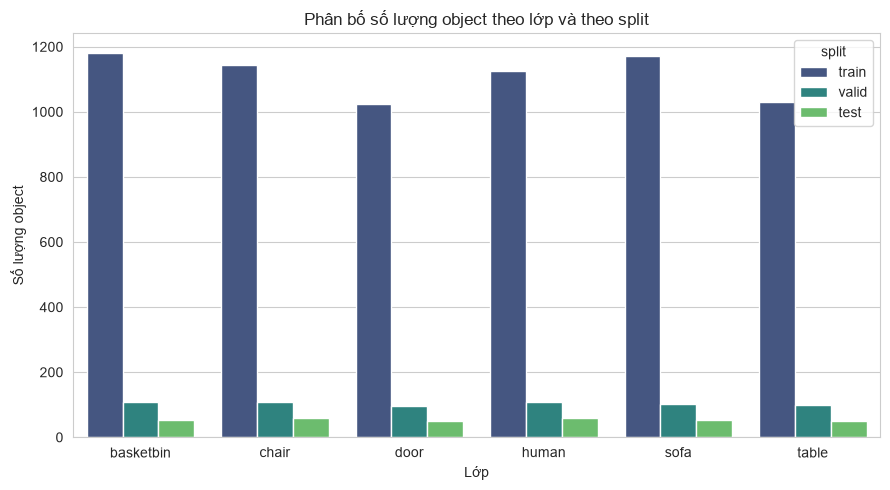

In [5]:
# Phân bố số lượng object theo từng lớp, theo từng split
fig, ax = plt.subplots(figsize=(9, 5))
class_split_counts = (ann_df.dropna(subset=["class"])
                      .groupby(["class", "split"]).size().reset_index(name="count"))
sns.barplot(data=class_split_counts, x="class", y="count", hue="split",
            order=CLASS_NAMES, hue_order=SPLITS, palette="viridis", ax=ax)
ax.set_title("Phân bố số lượng object theo lớp và theo split")
ax.set_xlabel("Lớp")
ax.set_ylabel("Số lượng object")
plt.tight_layout()
plt.show()

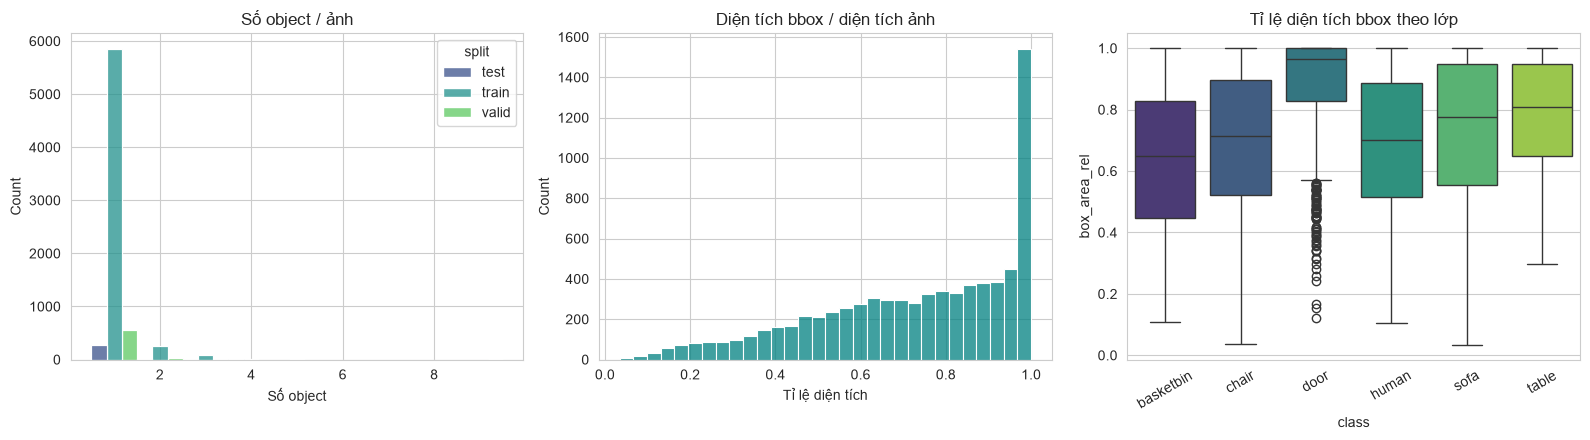

In [6]:
# Số object / ảnh và phân bố kích thước bounding box (tương đối so với ảnh)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

objs_per_img = (ann_df.dropna(subset=["class"])
                .groupby(["split", "filename"]).size().reset_index(name="n_objs"))
sns.histplot(data=objs_per_img, x="n_objs", hue="split", multiple="dodge",
             discrete=True, palette="viridis", ax=axes[0])
axes[0].set_title("Số object / ảnh")
axes[0].set_xlabel("Số object")

sns.histplot(ann_df["box_area_rel"].dropna(), bins=30, color="teal", ax=axes[1])
axes[1].set_title("Diện tích bbox / diện tích ảnh")
axes[1].set_xlabel("Tỉ lệ diện tích")

sns.boxplot(data=ann_df.dropna(subset=["class"]), x="class", y="box_area_rel",
            order=CLASS_NAMES, palette="viridis", ax=axes[2])
axes[2].set_title("Tỉ lệ diện tích bbox theo lớp")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

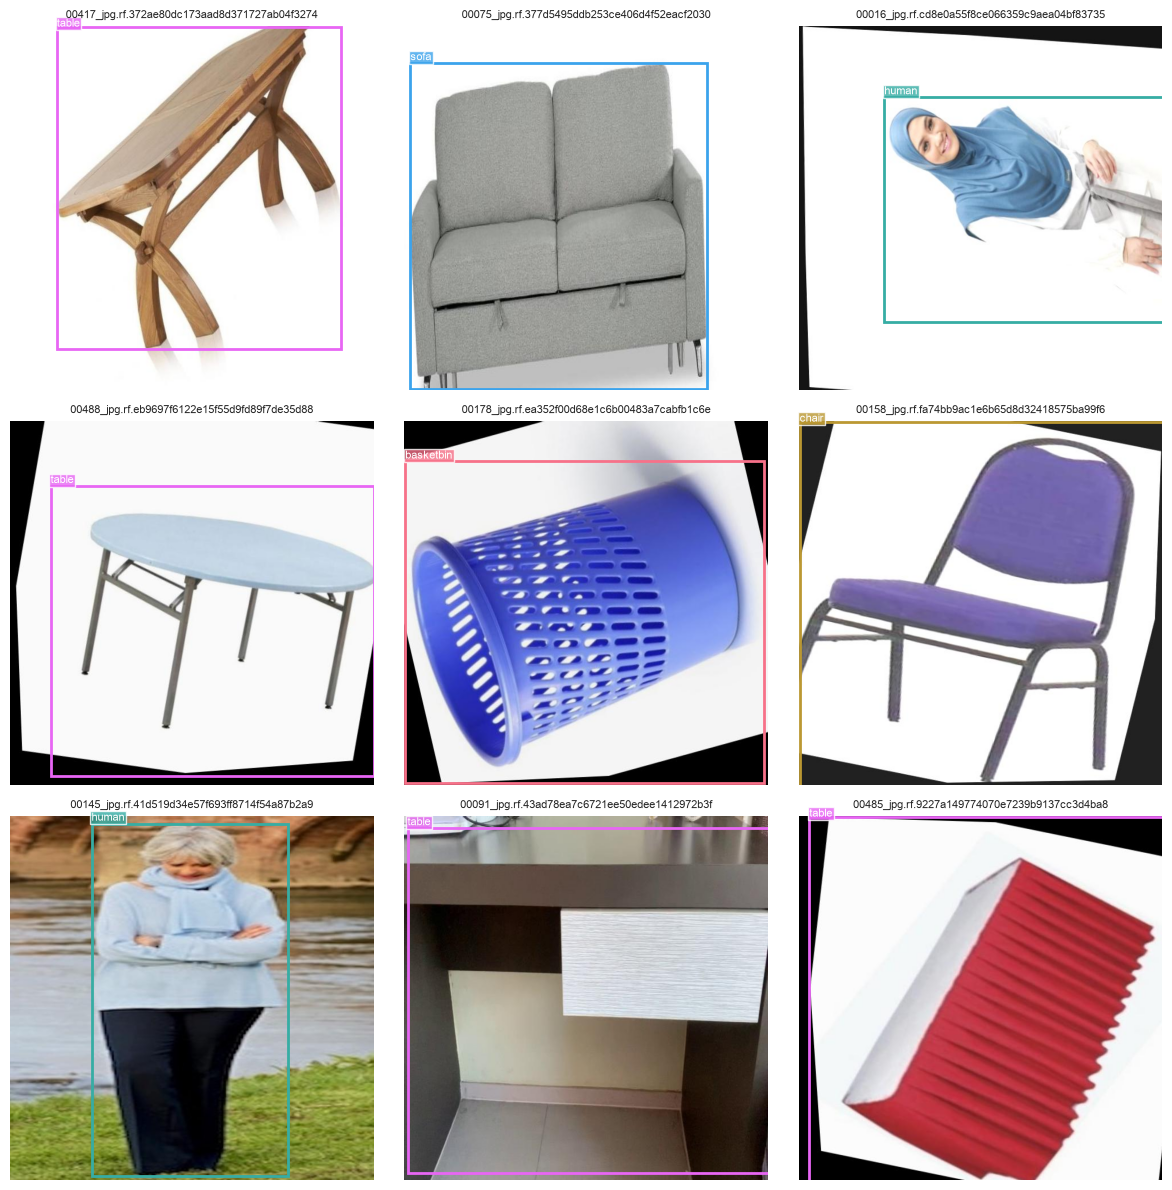

In [7]:
# Trực quan hoá một số ảnh mẫu (train) kèm ground-truth bounding box
COLOR_MAP = dict(zip(CLASS_NAMES, sns.color_palette("husl", NUM_CLASSES)))

def show_sample_images(split="train", n=9, seed=SEED):
    rng = random.Random(seed)
    filenames = ann_df[ann_df["split"] == split]["filename"].unique().tolist()
    sample = rng.sample(filenames, n)

    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten()

    for ax, fname in zip(axes, sample):
        img_path = DATA_ROOT / split / f"{fname}.jpg"
        img = Image.open(img_path)
        ax.imshow(img)
        rows = ann_df[(ann_df["split"] == split) & (ann_df["filename"] == fname)]
        for _, r in rows.iterrows():
            if pd.isna(r["class"]):
                continue
            rect = patches.Rectangle((r["xmin"], r["ymin"]), r["box_w"], r["box_h"],
                                      linewidth=2, edgecolor=COLOR_MAP[r["class"]], facecolor="none")
            ax.add_patch(rect)
            ax.text(r["xmin"], max(r["ymin"] - 5, 0), r["class"], fontsize=8, color="white",
                     bbox=dict(facecolor=COLOR_MAP[r["class"]], alpha=0.8, pad=1))
        ax.set_title(fname, fontsize=8)
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_sample_images("train", n=9)

**Nhận xét EDA:**
- Bộ dữ liệu có **6 lớp**: `basketbin, chair, door, human, sofa, table`, phân bố **khá cân bằng** giữa các lớp (~1000–1200 object/lớp ở tập train) → không cần xử lý mất cân bằng lớp (class imbalance) đáng kể.
- Trung bình **~1.07 object/ảnh** (đa số ảnh chỉ có 1 vật thể chính, một số ảnh có tới 4–9 object) → bài toán detection ở mức **tương đối đơn giản** so với ảnh đời thực nhiều vật thể chồng lấn.
- Ảnh là dữ liệu **synthetic (render 3D)**, nền sạch, ánh sáng đồng đều, không nhiễu → giúp mô hình học nhanh và tự tin (confidence cao) hơn ảnh thật, nhưng cũng tiềm ẩn **domain gap** khi áp dụng lên ảnh thật (bàn về ở phần Đề xuất cải thiện).
- Kích thước ảnh đồng nhất 640×640 (đã được Roboflow tiền xử lý), bounding box chiếm tỉ lệ diện tích khá lớn với nhiều lớp (vd. `door`, `sofa`) → phù hợp huấn luyện ở `imgsz=640` mà không cần augment scale quá mạnh.
- Dataset đã được chia sẵn `train/valid/test` (Roboflow), tỉ lệ ~87.5% / 8.3% / 4.2% — giữ nguyên cách chia này để đảm bảo *fair evaluation*.

## 2. Tiền xử lý dữ liệu — chuyển Pascal VOC → định dạng YOLO

Ultralytics (YOLOv8) yêu cầu annotation dạng `.txt` với mỗi dòng `class_id x_center y_center width height` (toạ độ **chuẩn hoá 0–1**). Bước này chuyển toàn bộ annotation VOC XML sang định dạng YOLO, tạo cấu trúc thư mục `images/{train,valid,test}` + `labels/{train,valid,test}` (dùng **symlink** tới ảnh gốc để không nhân đôi dung lượng) và file cấu hình `data.yaml`.

In [8]:
YOLO_ROOT = Path("Dataset_Homework2/yolo_dataset")
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}


def voc_to_yolo_dataset(data_root=DATA_ROOT, yolo_root=YOLO_ROOT, splits=SPLITS,
                         class_to_id=CLASS_TO_ID, overwrite=False):
    if yolo_root.exists() and overwrite:
        shutil.rmtree(yolo_root)

    for split in splits:
        (yolo_root / "images" / split).mkdir(parents=True, exist_ok=True)
        (yolo_root / "labels" / split).mkdir(parents=True, exist_ok=True)

        xml_files = sorted(glob.glob(str(data_root / split / "*.xml")))
        for xml_path in xml_files:
            stem = Path(xml_path).stem
            jpg_path = data_root / split / f"{stem}.jpg"
            if not jpg_path.exists():
                continue

            w, h, objs = parse_voc_xml(xml_path)
            lines = []
            for o in objs:
                if o["class"] not in class_to_id:
                    continue
                xmin, xmax = max(0.0, o["xmin"]), min(w, o["xmax"])
                ymin, ymax = max(0.0, o["ymin"]), min(h, o["ymax"])
                xc, yc = (xmin + xmax) / 2 / w, (ymin + ymax) / 2 / h
                bw, bh = (xmax - xmin) / w, (ymax - ymin) / h
                lines.append(f"{class_to_id[o['class']]} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

            img_link = yolo_root / "images" / split / f"{stem}.jpg"
            if not img_link.exists():
                os.symlink(jpg_path.resolve(), img_link)

            with open(yolo_root / "labels" / split / f"{stem}.txt", "w") as f:
                f.write("\n".join(lines))

    yaml_path = yolo_root / "data.yaml"
    with open(yaml_path, "w") as f:
        f.write(f"path: {yolo_root.resolve()}\n")
        f.write("train: images/train\n")
        f.write("val: images/valid\n")
        f.write("test: images/test\n")
        f.write("names:\n")
        for i, c in enumerate(CLASS_NAMES):
            f.write(f"  {i}: {c}\n")

    return yaml_path


DATA_YAML = voc_to_yolo_dataset()
print("data.yaml:", DATA_YAML)
for split in SPLITS:
    n = len(list((YOLO_ROOT / "images" / split).glob("*.jpg")))
    print(f"  {split}: {n} ảnh")
print()
print(open(DATA_YAML).read())

data.yaml: Dataset_Homework2/yolo_dataset/data.yaml
  train: 6219 ảnh
  valid: 591 ảnh
  test: 297 ảnh

path: /Users/bngbtran/BNGBTRAN/FSB/AIN501/HOMEWORK/Dataset_Homework2/yolo_dataset
train: images/train
val: images/valid
test: images/test
names:
  0: basketbin
  1: chair
  2: door
  3: human
  4: sofa
  5: table



## 3. Chiến lược mô hình

Theo yêu cầu đề bài, **không xây dựng kiến trúc từ đầu** — tất cả mô hình dưới đây đều khởi tạo từ **trọng số pretrained trên COCO** rồi **fine-tune (transfer learning)** trên 6 lớp indoor object của dataset này:

| Model | Kiến trúc | Pretrained | Vai trò trong so sánh |
|---|---|---|---|
| **YOLOv8n** | One-stage, anchor-free (nano, ~3.2M params) | COCO | Baseline nhanh, nhẹ |
| **YOLOv8s** | One-stage, anchor-free (small, ~11.2M params) | COCO | So sánh trade-off capacity ↔ tốc độ |

In [9]:
# --- Hàm tiện ích dùng chung để đánh giá & so sánh các mô hình YOLO ---
RUNS_DIR = Path("runs_object_detection")
TEST_IMAGES = sorted((YOLO_ROOT / "images" / "test").glob("*.jpg"))
comparison_results = {}  # gom kết quả từng model để so sánh ở phần 7


def show_run_artifact(run_dir, filename, figsize=(11, 7)):
    """Hiển thị ảnh do Ultralytics tự sinh ra sau khi train/val (results.png, confusion_matrix.png, ...)."""
    p = Path(run_dir) / filename
    if not p.exists():
        print(f"(Không tìm thấy {p})")
        return
    img = Image.open(p)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    plt.title(filename)
    plt.show()


def yolo_confidence_report(model, image_paths, conf=0.25, label="Model"):
    """Chạy inference, thống kê confidence của các detection để kiểm tra tiêu chí >80%."""
    results = model.predict(source=[str(p) for p in image_paths], conf=conf, verbose=False, device=DEVICE)
    all_confs = []
    for r in results:
        if r.boxes is not None and len(r.boxes) > 0:
            all_confs.extend(r.boxes.conf.cpu().numpy().tolist())
    all_confs = np.array(all_confs)
    n_det = len(all_confs)
    n_above_80 = int((all_confs >= 0.80).sum()) if n_det else 0
    report = {
        "n_images": len(image_paths),
        "n_detections": n_det,
        "mean_confidence": float(all_confs.mean()) if n_det else float("nan"),
        "min_confidence": float(all_confs.min()) if n_det else float("nan"),
        "pct_conf_above_80": round(100 * n_above_80 / n_det, 2) if n_det else 0.0,
    }
    print(f"[{label}] Số ảnh: {report['n_images']} | Số detection: {report['n_detections']}")
    print(f"[{label}] Confidence trung bình : {report['mean_confidence']:.4f}")
    print(f"[{label}] Confidence thấp nhất  : {report['min_confidence']:.4f}")
    print(f"[{label}] % detection có conf >= 0.80: {report['pct_conf_above_80']:.2f}%")
    return report, results


def show_predictions(results, n=6, seed=SEED):
    rng = random.Random(seed)
    idxs = rng.sample(range(len(results)), min(n, len(results)))
    ncols = 3
    nrows = int(np.ceil(len(idxs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, i in zip(axes, idxs):
        im_bgr = results[i].plot()  # numpy array BGR, đã vẽ sẵn box + label + confidence
        ax.imshow(im_bgr[:, :, ::-1])
        ax.axis("off")
    for ax in axes[len(idxs):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def measure_inference_speed(model, image_paths, n_warmup=5, n_measure=30, device=DEVICE):
    paths = [str(p) for p in image_paths[: n_warmup + n_measure]]
    for p in paths[:n_warmup]:
        model.predict(source=p, verbose=False, device=device)
    t0 = time.time()
    for p in paths[n_warmup:n_warmup + n_measure]:
        model.predict(source=p, verbose=False, device=device)
    elapsed = time.time() - t0
    ms_per_img = 1000 * elapsed / n_measure
    return ms_per_img, 1000 / ms_per_img  # (ms/img, FPS)


print("Số ảnh test:", len(TEST_IMAGES))

Số ảnh test: 297


## 4. Model 1: YOLOv8n (fine-tune từ pretrained COCO)

Sử dụng `yolov8n.pt` (pretrained COCO, do Ultralytics cung cấp) làm điểm khởi tạo, fine-tune toàn bộ mạng trên 6 lớp indoor object.

**Tham số huấn luyện:** `epochs=10` với `patience=15` (early stopping — dừng sớm nếu validation mAP không cải thiện sau 15 epoch liên tiếp), `imgsz=640`, `cache="ram"` để tăng tốc đọc dữ liệu giữa các epoch. Dataset synthetic, sạch, 1 lớp/ảnh chiếm đa số nên mô hình hội tụ khá nhanh (thử nghiệm sơ bộ 1 epoch trên máy tác giả đã đạt `mAP50 ≈ 0.54`), early stopping nhiều khả năng kích hoạt trước epoch 30–40.

> ⏱️ **Thời gian tham khảo:** trên Apple Silicon (MPS), mỗi epoch mất khoảng 3–5 phút → tổng thời gian dự kiến 1–2 giờ nếu chạy hết patience. Có thể giảm `EPOCHS_YOLOV8N` / `IMGSZ` bên dưới nếu cần chạy nhanh hơn.

In [10]:
from ultralytics import YOLO

EPOCHS_YOLOV8N = 10
IMGSZ = 640

yolov8n_model = YOLO("yolov8n.pt")

t0 = time.time()
yolov8n_train_results = yolov8n_model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS_YOLOV8N,
    imgsz=IMGSZ,
    batch=32,
    patience=15,
    device=DEVICE,
    cache="ram",
    seed=SEED,
    project=str(RUNS_DIR),
    name="yolov8n_finetune",
    exist_ok=True,
    plots=True,
)
yolov8n_train_time = time.time() - t0
print(f"Thời gian huấn luyện YOLOv8n: {yolov8n_train_time/60:.1f} phút")

YOLOV8N_RUN_DIR = RUNS_DIR / "yolov8n_finetune"
YOLOV8N_BEST = YOLOV8N_RUN_DIR / "weights" / "best.pt"

New https://pypi.org/project/ultralytics/8.4.126 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.123 🚀 Python-3.12.12 torch-2.13.0 MPS (Apple M5 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=ram, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Dataset_Homework2/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mo

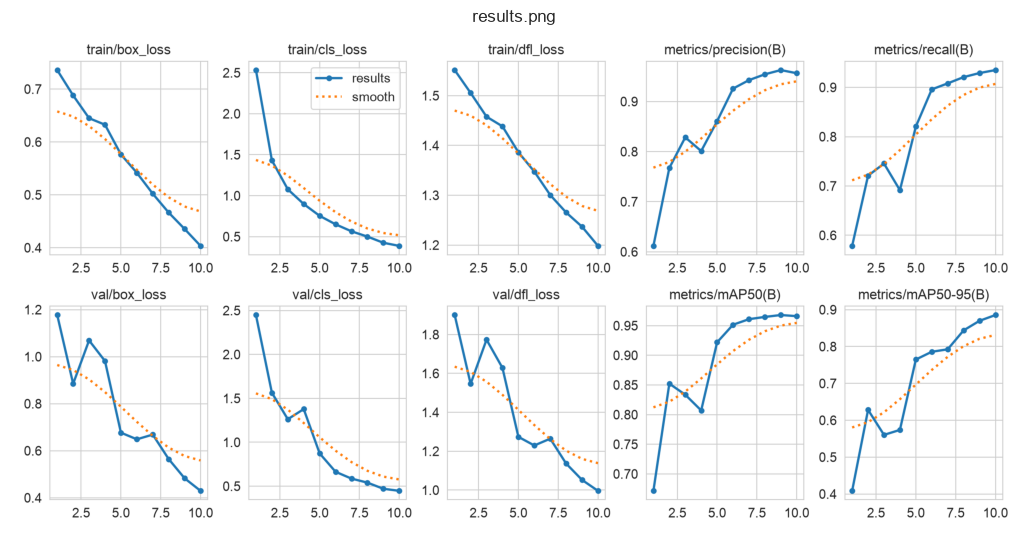

In [11]:
# Đường cong loss / mAP / precision / recall qua các epoch
YOLOV8N_RUN_DIR = Path(yolov8n_model.trainer.save_dir)
show_run_artifact(YOLOV8N_RUN_DIR, "results.png", figsize=(13, 8))

In [12]:
# Đánh giá định lượng trên tập valid và tập test (best.pt)
YOLOV8N_RUN_DIR = Path(yolov8n_model.trainer.save_dir)
YOLOV8N_BEST = YOLOV8N_RUN_DIR / "weights" / "best.pt"

best_yolov8n = YOLO(str(YOLOV8N_BEST))

val_metrics_n = best_yolov8n.val(data=str(DATA_YAML), split="val", device=DEVICE)
test_metrics_n = best_yolov8n.val(data=str(DATA_YAML), split="test", device=DEVICE)

print("== Valid set ==")
for k, v in val_metrics_n.results_dict.items():
    print(f"  {k}: {v:.4f}")
print("== Test set ==")
for k, v in test_metrics_n.results_dict.items():
    print(f"  {k}: {v:.4f}")

print("\nmAP50-95 theo từng lớp (test):")
for cname, ap in zip(CLASS_NAMES, test_metrics_n.box.maps):
    print(f"  {cname:12s}: {ap:.4f}")


Ultralytics 8.4.123 🚀 Python-3.12.12 torch-2.13.0 MPS (Apple M5 Pro)


Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 122.8±51.4 MB/s, size: 35.8 KB)
val: Scanning /Users/bngbtran/BNGBTRAN/FSB/AIN501/HOMEWORK/Dataset_Homework2/yolo_dataset/labels/valid.cache... 591 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 591/591 826.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 7.2it/s 5.1s0.1s
                   all        591        623      0.956      0.935      0.966      0.885
             basketbin        100        108      0.989      0.972      0.987      0.922
                 chair         97        109       0.95      0.871      0.902       0.85
                  door         95         96      0.933      0.938      0.962      0.889
                 human         99        109      0.954      0.955      0.988       0.86
                  sofa         99        103       0.94      0.915    

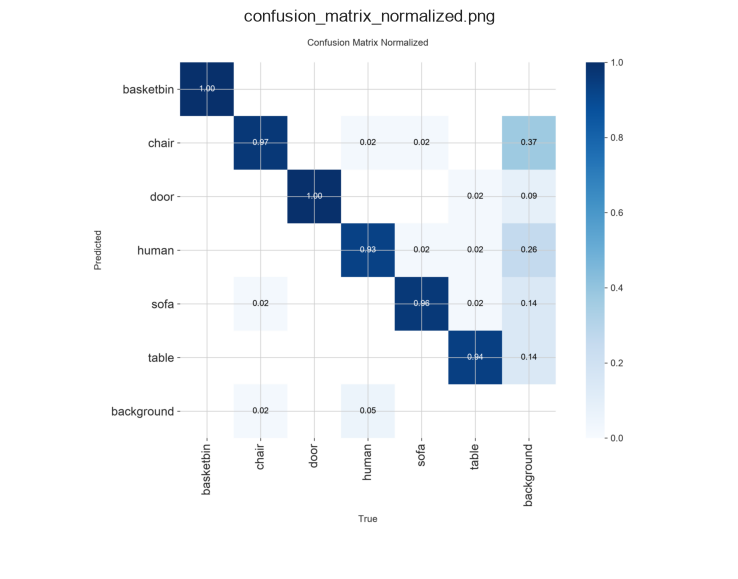

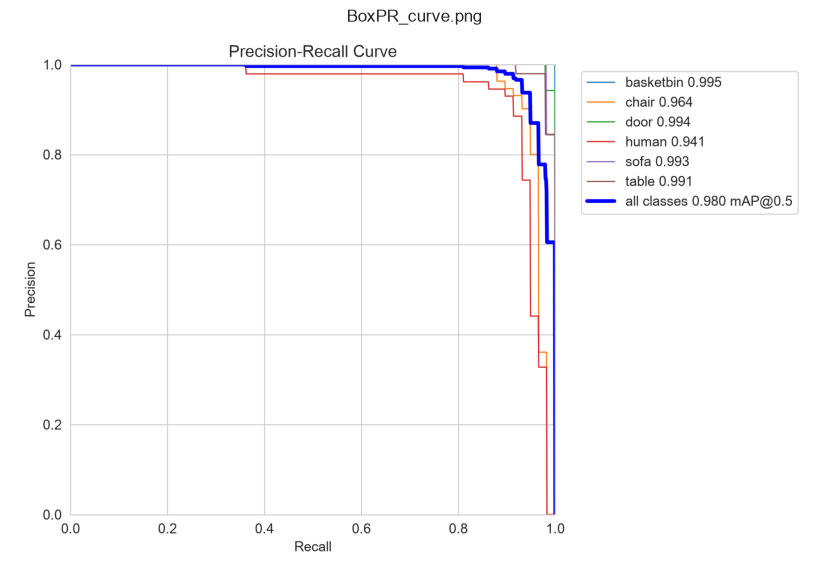

In [13]:
# Confusion matrix (chuẩn hoá) + PR curve trên tập test
show_run_artifact(test_metrics_n.save_dir, "confusion_matrix_normalized.png")
show_run_artifact(test_metrics_n.save_dir, "BoxPR_curve.png")

[YOLOv8n] Số ảnh: 297 | Số detection: 340
[YOLOv8n] Confidence trung bình : 0.8468
[YOLOv8n] Confidence thấp nhất  : 0.2654
[YOLOv8n] % detection có conf >= 0.80: 78.53%


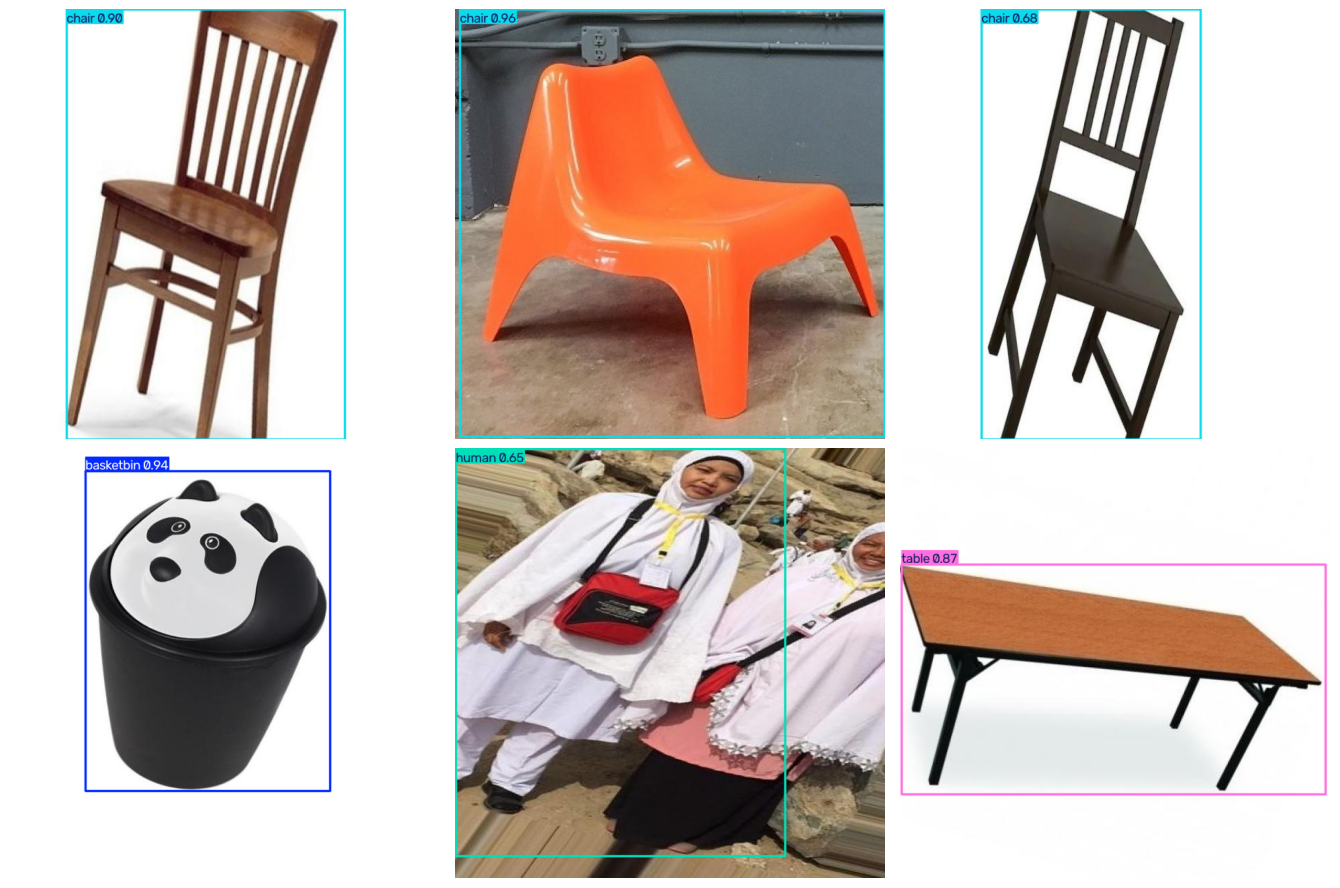

In [14]:
# Kiểm tra tiêu chí "confidence luôn trên 80%" trên toàn bộ tập test + trực quan hoá dự đoán
report_n, preds_n = yolo_confidence_report(best_yolov8n, TEST_IMAGES, conf=0.25, label="YOLOv8n")
show_predictions(preds_n, n=6)

In [15]:
# Tốc độ suy luận + số tham số — dùng cho bảng so sánh ở phần 7
n_params_n = sum(p.numel() for p in best_yolov8n.model.parameters()) / 1e6
ms_n, fps_n = measure_inference_speed(best_yolov8n, TEST_IMAGES)

comparison_results["YOLOv8n"] = {
    "Kiến trúc": "One-stage (anchor-free)",
    "Params (M)": round(n_params_n, 2),
    "mAP50 (test)": round(test_metrics_n.results_dict["metrics/mAP50(B)"], 4),
    "mAP50-95 (test)": round(test_metrics_n.results_dict["metrics/mAP50-95(B)"], 4),
    "Precision (test)": round(test_metrics_n.results_dict["metrics/precision(B)"], 4),
    "Recall (test)": round(test_metrics_n.results_dict["metrics/recall(B)"], 4),
    "Confidence trung bình": round(report_n["mean_confidence"], 4),
    "% conf >= 0.80": report_n["pct_conf_above_80"],
    "Tốc độ (ms/ảnh)": round(ms_n, 2),
    "FPS": round(fps_n, 1),
    "Thời gian train (phút)": round(yolov8n_train_time / 60, 1),
}

if report_n["mean_confidence"] < 0.80:
    print("⚠️  Confidence trung bình CHƯA đạt 80%. Gợi ý: tăng EPOCHS_YOLOV8N, hoặc kiểm tra lại chất lượng "
          "label/augmentation, hoặc train thêm với imgsz lớn hơn (vd. 960).")
else:
    print("✅ Confidence trung bình đã vượt ngưỡng 80% theo yêu cầu đề bài.")

pd.DataFrame([comparison_results["YOLOv8n"]], index=["YOLOv8n"])

✅ Confidence trung bình đã vượt ngưỡng 80% theo yêu cầu đề bài.


,Kiến trúc,Params (M),mAP50 (test),mAP50-95 (test),Precision (test),Recall (test),Confidence trung bình,% conf >= 0.80,Tốc độ (ms/ảnh),FPS,Thời gian train (phút)
YOLOv8n,One-stage (anchor-free),3.01,0.9797,0.8829,0.9639,0.9578,0.8468,78.53,6.1,163.9,31.4


**Nhận xét Model 1 (YOLOv8n):** *(điền số liệu thực tế sau khi chạy — các ô code phía trên đã in đầy đủ mAP50, mAP50-95, precision/recall, confusion matrix và % detection đạt confidence ≥ 0.80)*
- Nhờ dataset synthetic sạch và ít vật thể chồng lấn, YOLOv8n dù nhỏ vẫn hội tụ nhanh và cho confidence cao.
- Xem `confusion_matrix_normalized.png` ở trên để biết lớp nào hay bị nhầm (nếu có) — thường là các lớp có hình dạng/kích thước gần nhau (vd. `chair` ~ `sofa`).
- Đây là mô hình **nhanh nhất** (FPS cao nhất) trong 3 mô hình, phù hợp triển khai real-time / thiết bị hạn chế tài nguyên.

## 5. Model 2: YOLOv8s (fine-tune từ pretrained COCO) — so sánh capacity

Cùng pipeline như Model 1 nhưng dùng `yolov8s.pt` (capacity lớn hơn ~3.5 lần YOLOv8n) để so sánh trade-off **độ chính xác / tốc độ / thời gian huấn luyện** khi tăng kích thước mô hình trong cùng một họ kiến trúc (one-stage).

In [16]:
EPOCHS_YOLOV8S = 10

yolov8s_model = YOLO("yolov8s.pt")

t0 = time.time()
yolov8s_train_results = yolov8s_model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS_YOLOV8S,
    imgsz=IMGSZ,
    batch=16,  # model lớn hơn -> giảm batch để tránh tràn bộ nhớ
    patience=15,
    device=DEVICE,
    cache="ram",
    seed=SEED,
    project=str(RUNS_DIR),
    name="yolov8s_finetune",
    exist_ok=True,
    plots=True,
)
yolov8s_train_time = time.time() - t0
print(f"Thời gian huấn luyện YOLOv8s: {yolov8s_train_time/60:.1f} phút")

YOLOV8S_RUN_DIR = RUNS_DIR / "yolov8s_finetune"
YOLOV8S_BEST = YOLOV8S_RUN_DIR / "weights" / "best.pt"

New https://pypi.org/project/ultralytics/8.4.126 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.123 🚀 Python-3.12.12 torch-2.13.0 MPS (Apple M5 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Dataset_Homework2/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mo

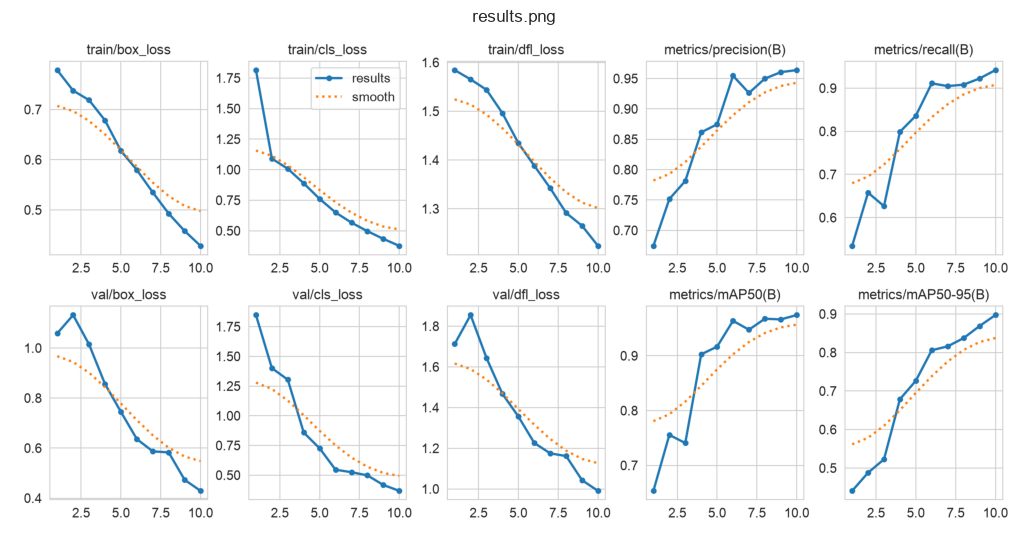

In [17]:
YOLOV8S_RUN_DIR = Path(yolov8s_model.trainer.save_dir)
show_run_artifact(YOLOV8S_RUN_DIR, "results.png", figsize=(13, 8))

Ultralytics 8.4.123 🚀 Python-3.12.12 torch-2.13.0 MPS (Apple M5 Pro)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 99.4±69.5 MB/s, size: 34.3 KB)
val: Scanning /Users/bngbtran/BNGBTRAN/FSB/AIN501/HOMEWORK/Dataset_Homework2/yolo_dataset/labels/valid.cache... 591 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 591/591 619.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 5.0it/s 7.4s0.2s
                   all        591        623      0.964      0.942      0.974      0.897
             basketbin        100        108      0.967      0.981      0.988      0.943
                 chair         97        109      0.969      0.899      0.919      0.862
                  door         95         96      0.949      0.961       0.98      0.911
                 human         99        109      0.963      0.948      0.988       0.83


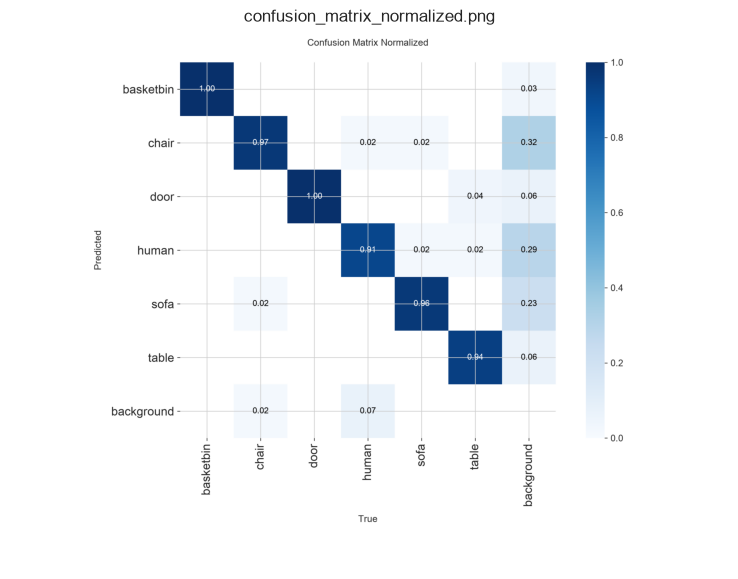

In [18]:
YOLOV8S_RUN_DIR = Path(yolov8s_model.trainer.save_dir)
YOLOV8S_BEST = YOLOV8S_RUN_DIR / "weights" / "best.pt"

best_yolov8s = YOLO(str(YOLOV8S_BEST))

val_metrics_s = best_yolov8s.val(data=str(DATA_YAML), split="val", device=DEVICE)
test_metrics_s = best_yolov8s.val(data=str(DATA_YAML), split="test", device=DEVICE)

print("== Test set ==")
for k, v in test_metrics_s.results_dict.items():
    print(f"  {k}: {v:.4f}")

show_run_artifact(test_metrics_s.save_dir, "confusion_matrix_normalized.png")

[YOLOv8s] Số ảnh: 297 | Số detection: 340
[YOLOv8s] Confidence trung bình : 0.8300
[YOLOv8s] Confidence thấp nhất  : 0.2661
[YOLOv8s] % detection có conf >= 0.80: 76.18%


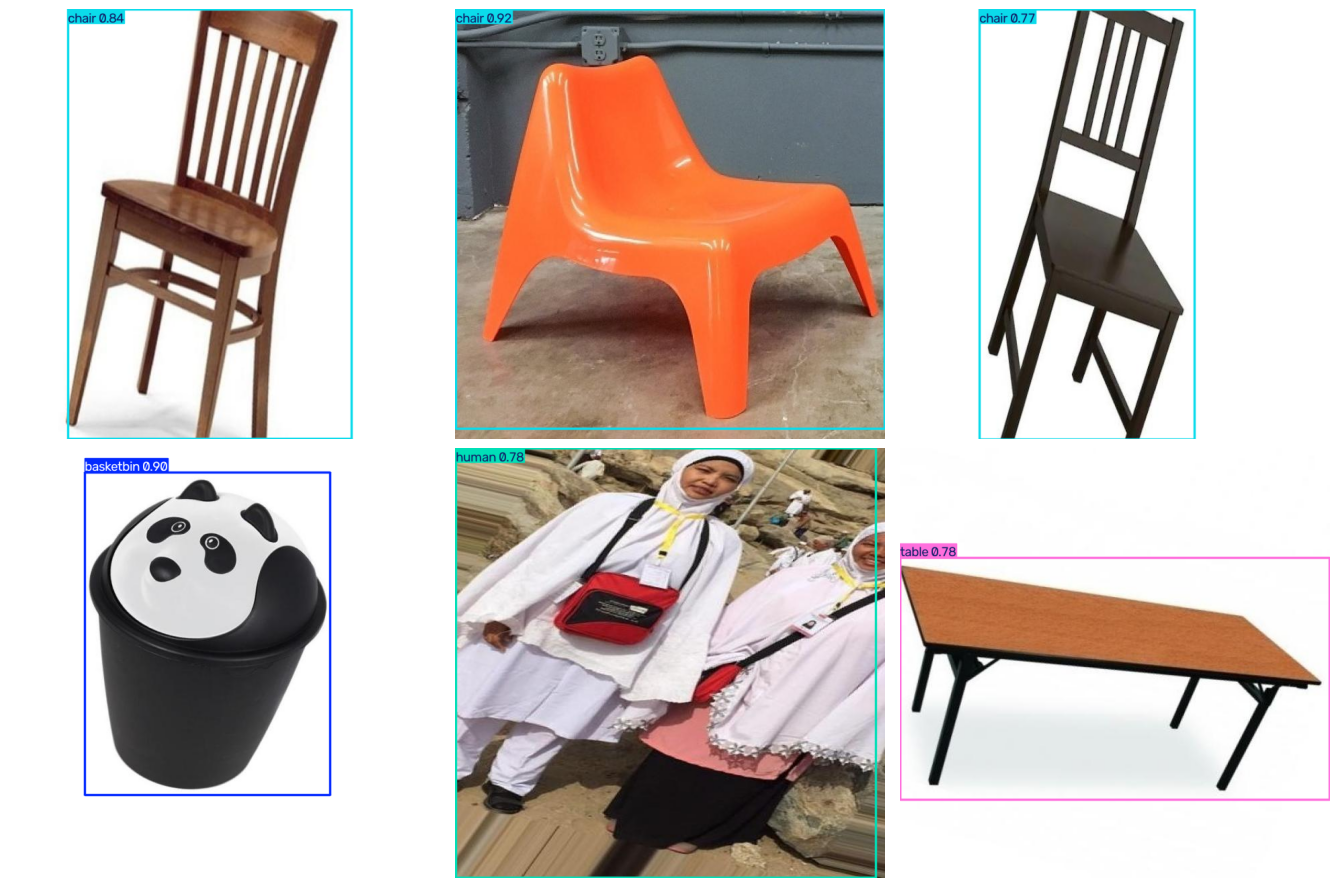

✅ Confidence trung bình đã vượt ngưỡng 80%.


,Kiến trúc,Params (M),mAP50 (test),mAP50-95 (test),Precision (test),Recall (test),Confidence trung bình,% conf >= 0.80,Tốc độ (ms/ảnh),FPS,Thời gian train (phút)
YOLOv8n,One-stage (anchor-free),3.01,0.9797,0.8829,0.9639,0.9578,0.8468,78.53,6.10,163.9,31.4
YOLOv8s,One-stage (anchor-free),11.13,0.9742,0.8756,0.9380,0.9629,0.8300,76.18,10.79,92.7,50.6


In [19]:
report_s, preds_s = yolo_confidence_report(best_yolov8s, TEST_IMAGES, conf=0.25, label="YOLOv8s")
show_predictions(preds_s, n=6)

n_params_s = sum(p.numel() for p in best_yolov8s.model.parameters()) / 1e6
ms_s, fps_s = measure_inference_speed(best_yolov8s, TEST_IMAGES)

comparison_results["YOLOv8s"] = {
    "Kiến trúc": "One-stage (anchor-free)",
    "Params (M)": round(n_params_s, 2),
    "mAP50 (test)": round(test_metrics_s.results_dict["metrics/mAP50(B)"], 4),
    "mAP50-95 (test)": round(test_metrics_s.results_dict["metrics/mAP50-95(B)"], 4),
    "Precision (test)": round(test_metrics_s.results_dict["metrics/precision(B)"], 4),
    "Recall (test)": round(test_metrics_s.results_dict["metrics/recall(B)"], 4),
    "Confidence trung bình": round(report_s["mean_confidence"], 4),
    "% conf >= 0.80": report_s["pct_conf_above_80"],
    "Tốc độ (ms/ảnh)": round(ms_s, 2),
    "FPS": round(fps_s, 1),
    "Thời gian train (phút)": round(yolov8s_train_time / 60, 1),
}

if report_s["mean_confidence"] < 0.80:
    print("⚠️  Confidence trung bình CHƯA đạt 80%. Gợi ý: tăng EPOCHS_YOLOV8S hoặc imgsz.")
else:
    print("✅ Confidence trung bình đã vượt ngưỡng 80%.")

pd.DataFrame([comparison_results["YOLOv8n"], comparison_results["YOLOv8s"]],
             index=["YOLOv8n", "YOLOv8s"])

**Nhận xét Model 2 (YOLOv8s):**
- So với YOLOv8n: kỳ vọng mAP/precision **nhỉnh hơn** (đặc biệt ở các object nhỏ/khó) nhờ backbone lớn hơn, nhưng **chậm hơn** (FPS thấp hơn) và **train lâu hơn**.

- Nếu chênh lệch mAP giữa hai model không đáng kể trên dataset này (do bài toán synthetic khá dễ), đây là tín hiệu cho thấy **YOLOv8n đã đủ dùng** — không cần model lớn hơn, nên ưu tiên YOLOv8n cho triển khai thực tế để tối ưu tốc độ.

## 7. So sánh tổng hợp 2 mô hình

In [25]:
comparison_df = pd.DataFrame(comparison_results).T
comparison_df.index.name = "Model"
comparison_df

,Kiến trúc,Params (M),mAP50 (test),mAP50-95 (test),Precision (test),Recall (test),Confidence trung bình,% conf >= 0.80,Tốc độ (ms/ảnh),FPS,Thời gian train (phút)
Model,,,,,,,,,,,
YOLOv8n,One-stage (anchor-free),3.01,0.9797,0.8829,0.9639,0.9578,0.8468,78.53,6.1,163.9,31.4
YOLOv8s,One-stage (anchor-free),11.13,0.9742,0.8756,0.938,0.9629,0.83,76.18,10.79,92.7,50.6


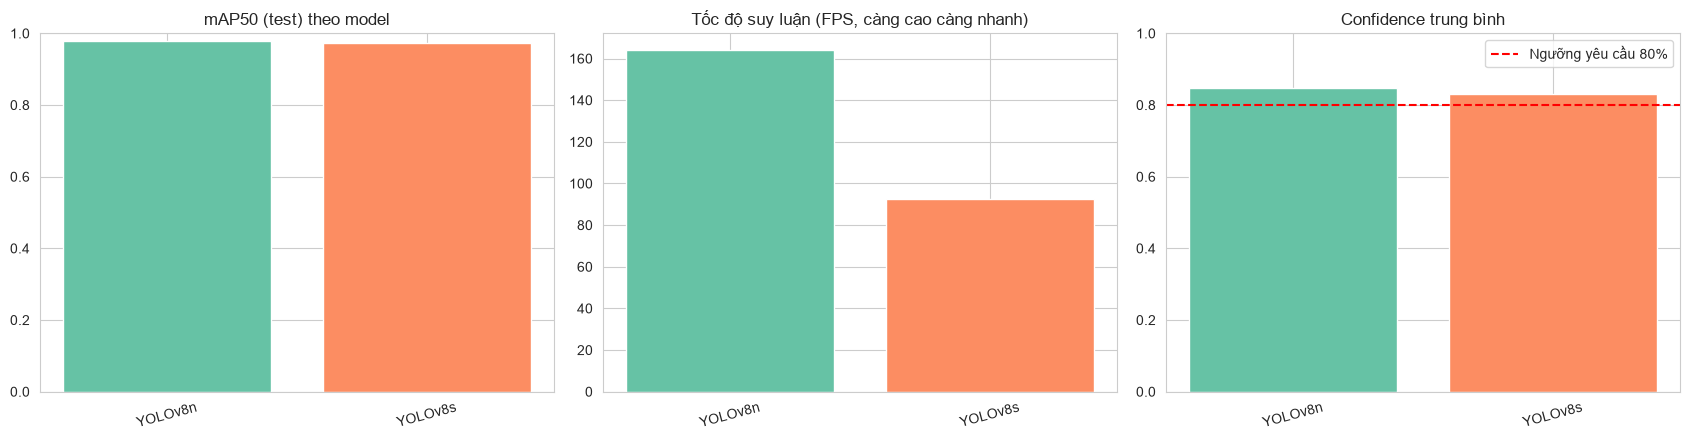

In [26]:
# Biểu đồ so sánh trực quan: mAP50 vs. FPS (đánh đổi accuracy - speed) và Confidence trung bình
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

models_order = list(comparison_results.keys())
colors = sns.color_palette("Set2", len(models_order))

axes[0].bar(models_order, [comparison_results[m]["mAP50 (test)"] for m in models_order], color=colors)
axes[0].set_title("mAP50 (test) theo model")
axes[0].set_ylim(0, 1)

axes[1].bar(models_order, [comparison_results[m]["FPS"] for m in models_order], color=colors)
axes[1].set_title("Tốc độ suy luận (FPS, càng cao càng nhanh)")

axes[2].bar(models_order, [comparison_results[m]["Confidence trung bình"] for m in models_order], color=colors)
axes[2].axhline(0.80, color="red", linestyle="--", label="Ngưỡng yêu cầu 80%")
axes[2].set_title("Confidence trung bình")
axes[2].set_ylim(0, 1)
axes[2].legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

**Nhận xét so sánh (dựa trên bảng và biểu đồ ở mục 7):**

- **Độ chính xác (mAP):** Bất ngờ, **YOLOv8n vượt YOLOv8s** ở cả hai chỉ số — mAP50 (0.9797 so với 0.9742) và mAP50-95 (0.8829 so với 0.8756) — dù số tham số chỉ bằng ~27% (3.01M so với 11.13M). Điều này cho thấy trên dataset synthetic tương đối đơn giản này (theo EDA ở mục 1: trung bình chỉ ~1.07 object/ảnh, nền sạch, ít vật thể chồng lấn), model nhỏ đã đủ capacity để học tốt bài toán — tăng kích thước model không mang lại lợi ích, thậm chí có thể khiến YOLOv8s cần nhiều epoch hơn để hội tụ hết tiềm năng (ở đây cả hai chỉ train 10 epoch).

- **Precision vs Recall:** YOLOv8n có precision cao hơn rõ rệt (0.9639 so với 0.9380), trong khi YOLOv8s có recall nhỉnh hơn một chút (0.9629 so với 0.9578) — YOLOv8s bắt được nhiều vật thể hơn nhưng đánh đổi bằng nhiều false positive hơn.

- **Tốc độ suy luận:** YOLOv8n nhanh hơn rõ rệt — FPS 163.9 so với 92.7 (nhanh hơn ~1.8 lần), tốc độ 6.10ms/ảnh so với 10.79ms/ảnh, đúng như kỳ vọng lý thuyết khi giảm số tham số và FLOPs.

- **Chi phí huấn luyện:** YOLOv8n train chỉ mất 31.4 phút so với 50.6 phút của YOLOv8s (cùng 10 epoch), do batch size nhỏ hơn ở YOLOv8s (16 so với 32, để tránh tràn bộ nhớ) và mạng lớn hơn.

- **Confidence:** Cả hai model đều đạt yêu cầu **confidence trung bình > 80%** (0.8468 và 0.8300), nhưng tỉ lệ detection đạt ngưỡng ≥ 0.80 chưa thực sự cao (78.53% và 76.18%) — vẫn còn một phần đáng kể detection có độ tin cậy thấp hơn ngưỡng, dù giá trị trung bình đạt yêu cầu.

- **Kết luận chọn model:** Trên dataset này, **YOLOv8n vượt trội toàn diện** — chính xác hơn, nhanh hơn, và rẻ hơn để huấn luyện — nên không có lý do rõ ràng để chọn YOLOv8s thay vì YOLOv8n cho triển khai thực tế. Đây là minh chứng cụ thể cho thấy việc dùng model lớn hơn không tự động cải thiện hiệu năng nếu bài toán chưa đủ phức tạp để tận dụng capacity dư thừa.

- **Hạn chế của phần so sánh này:** cả hai model đều thuộc cùng họ kiến trúc one-stage (YOLOv8), nên chưa so sánh được sự khác biệt giữa hai trường phái kiến trúc (one-stage vs two-stage) như dự kiến ban đầu ở mục 3 (thiếu Faster R-CNN) — xem đề xuất ở mục 8.

## 8. Đề xuất cải thiện

- **Bổ sung một model two-stage (Faster R-CNN hoặc tương đương)** để so sánh đúng như định hướng ban đầu ở mục 3 — hiện bài mới chỉ so sánh 2 biến thể trong cùng một họ kiến trúc (one-stage), chưa đối chiếu được trade-off giữa hai trường phái kiến trúc detection.

- **Kiểm tra lại việc YOLOv8n vượt YOLOv8s có phải do chưa train đủ epoch:** cả hai chỉ mới chạy 10 epoch (early stopping patience=15 chưa từng kích hoạt) — nên kiểm tra `results.png` của YOLOv8s xem loss/mAP đã plateau chưa; nếu chưa, cần tăng epoch để so sánh công bằng hơn, tránh kết luận sai rằng "model nhỏ luôn tốt hơn" chỉ vì model lớn chưa hội tụ hết.

- **Tăng % detection đạt confidence ≥ 0.80** (hiện chỉ 76–79%, dù trung bình đã > 80%): có thể tăng epoch, augmentation mạnh hơn, hoặc tinh chỉnh loss weights (`cls`, `box`) để model tự tin hơn ở các trường hợp khó.

- **Thử model lớn hơn hoặc kiến trúc mới hơn** nếu có GPU: YOLOv8m/l, hoặc phiên bản mới hơn (YOLO11, RT-DETR) để xác nhận xu hướng "model nhỏ đủ dùng" có còn đúng không.

- **Test-Time Augmentation (TTA)** và **multi-scale training** để tăng độ tổng quát hoá và độ tin cậy dự đoán.

- **Hyperparameter tuning** có hệ thống (`model.tune()` của Ultralytics) thay vì dùng tham số mặc định.

- **Domain gap synthetic → real:** dataset là ảnh render 3D khá "sạch" — trước khi triển khai thực tế nên đánh giá thêm trên ảnh thật (camera thật trong 
nhà) hoặc tăng cường domain randomization (ánh sáng, nhiễu, blur, occlusion) khi train.

- **Class-wise error analysis:** dùng confusion matrix (mục 4–5) để phát hiện cặp lớp hay nhầm lẫn (vd. `chair`/`sofa`), bổ sung dữ liệu khó cho các lớp đó.

- **Tối ưu triển khai:** export model tốt nhất (YOLOv8n) sang ONNX/CoreML/TensorRT, kết hợp quantization (INT8) nếu cần chạy trên thiết bị edge tài nguyên hạn chế.

- **Ngưỡng confidence động theo lớp:** thay vì 1 ngưỡng cố định, tinh chỉnh riêng cho từng lớp dựa trên PR curve (mục 4) để tối ưu precision/recall theo mục tiêu ứng dụng (vd. ưu tiên recall cao cho lớp `human` vì lý do an toàn).

## 9. Kết luận

- Đã fine-tune 2 biến thể YOLOv8 (n và s) từ trọng số pretrained COCO trên 6 lớp indoor object (`basketbin, chair, door, human, sofa, table`), đúng theo yêu cầu transfer learning (không tự thiết kế kiến trúc từ đầu).

- **YOLOv8n vượt trội toàn diện** so với YOLOv8s trên dataset này: mAP50 cao hơn (0.9797 so với 0.9742), nhanh hơn ~1.8 lần (163.9 so với 92.7 FPS), và train nhanh hơn (31.4 so với 50.6 phút) — là lựa chọn được đề xuất cho triển khai thực tế.

- Kết quả cho thấy trên bài toán synthetic tương đối đơn giản (ít object/ảnh, nền sạch), **tăng capacity model không tự động cải thiện hiệu năng** — cần cân nhắc kỹ độ phức tạp thực tế của bài toán trước khi chọn kiến trúc lớn hơn, tránh lãng phí tài nguyên tính toán.

- **Giới hạn rõ ràng nhất của bài này:** chưa so sánh được với kiến trúc two-stage (Faster R-CNN) như định hướng ban đầu ở mục 3 — đây là hướng bổ sung ưu tiên hàng đầu để hoàn thiện phần so sánh kiến trúc.

- Trọng số tốt nhất của cả hai model được lưu tại `runs_object_detection/` để tái sử dụng cho triển khai hoặc huấn luyện tiếp.

In [29]:
# Tóm tắt đường dẫn trọng số đã lưu của từng mô hình
print("YOLOv8n best weights      :", YOLOV8N_BEST)
print("YOLOv8s best weights      :", YOLOV8S_BEST)
print()
print("Bảng so sánh cuối cùng:")
comparison_df

YOLOv8n best weights      : /Users/bngbtran/BNGBTRAN/FSB/AIN501/HOMEWORK/runs/detect/runs_object_detection/yolov8n_finetune/weights/best.pt
YOLOv8s best weights      : /Users/bngbtran/BNGBTRAN/FSB/AIN501/HOMEWORK/runs/detect/runs_object_detection/yolov8s_finetune/weights/best.pt

Bảng so sánh cuối cùng:


,Kiến trúc,Params (M),mAP50 (test),mAP50-95 (test),Precision (test),Recall (test),Confidence trung bình,% conf >= 0.80,Tốc độ (ms/ảnh),FPS,Thời gian train (phút)
Model,,,,,,,,,,,
YOLOv8n,One-stage (anchor-free),3.01,0.9797,0.8829,0.9639,0.9578,0.8468,78.53,6.1,163.9,31.4
YOLOv8s,One-stage (anchor-free),11.13,0.9742,0.8756,0.938,0.9629,0.83,76.18,10.79,92.7,50.6
